<a href="https://colab.research.google.com/github/mugakami/deep-learning-intro/blob/main/deep-learning-intro%20/notebooks/01_perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# パーセプトロンとは

##本章の目的
<a>パーセプトロンは、ニューラルネットワークを構成する基本的な単位のひとつです<br>
この章では、パーセプトロンがどのような仕組みで入力を受け取り、<br>
出力を決めているのかを確認します。以下がパーセプトロンの概要図です。
入力データを受け取り、重みを掛け合わせて出力するかどうかを判別します。詳細はこの後追っていくので現時点で理解ができていなくても全く問題ありません。</a>

![パーセプトロンの図](https://raw.githubusercontent.com/mugakami/deep-learning-intro/main/images/perceptron.png)



## パーセプトロンとは

パーセプトロンは、**複数の入力を受け取り、それをもとに1つの出力を決める単純なモデル**です。  
ニューラルネットワークを構成する基本的な要素のひとつであり、入力された情報をもとに判断を行う最も基本的な仕組みです。

たとえば、ある条件を満たすときに 1、満たさないときに 0 を返すような、**二値分類の基本形**として捉えることができます。

---

## パーセプトロンの仕組み

パーセプトロンは、入力 （データ・与えられる値）`x1`, `x2` などを受け取り、それぞれに対応する重み（モデルや人が設定する値） `w1`, `w2` を掛け合わせます。  
さらに、そこに **バイアス**（モデルや人が設定する値） `b` を加えて、次の式を計算します。

$$
x_1 w_1 + x_2 w_2 + b
$$

そして、この値が **0 を超えるかどうか** で出力を決めます。
※1

- `x1*w1 + x2*w2 + b > 0` なら発火して `1`
- `x1*w1 + x2*w2 + b <= 0` なら発火せず `0`

このように、パーセプトロンは

**入力を受け取る → 重み付き和を計算する → バイアスを加える → 0 を超えたかどうかで出力を決める**

という流れで動作します。

---

## 重みとバイアスの役割

### 重み
重みは、**各入力がどれだけ出力に影響するか**を表します。

重みが大きい入力ほど結果に強く影響し、重みが小さい入力は影響が弱くなります。  
つまり、重みはそれぞれの入力の**重要度**を調整するための値です。

### バイアス
バイアスは、**どのくらい発火しやすいかを調整する値**です。

重み付き和だけだと、判定の基準が固定されてしまいます。  
そこでバイアスを加えることで、判定の境界を動かせるようになります。

直感的には、バイアスは  
**「どれくらい条件を満たせば 1 と判定するかを調整するための値」**  
と考えるとわかりやすいです。

---

## 発火する・しないとはどういうことか

パーセプトロンでは、計算結果が 0 を超えたときに「発火する」と表現します。  
これは、生物の神経細胞が一定以上の刺激を受けたときに反応するイメージになぞらえた言い方です。

ただし、ここでは難しく考えすぎず、

- 条件を満たしたら `1`
- 条件を満たさなければ `0`

と出力を決める仕組みだと考えれば十分です。

---

## パーセプトロンでできること

パーセプトロンは、入力に対して単純な判定を行うことができます。  
たとえば、AND や OR のような論理回路は、適切な重みとバイアスを設定することで表現できます。

このことから、パーセプトロンは  
**入力から出力を決める基本的な判定装置**  
として理解できます。

---

言葉だけの説明では理解が難しいと思うので、以下で実際にパーセプトロンを動かして理解を深めてみましょう。

---

※1
パーセプトロンでは 0 を境に出力を切り替えます。 後で学ぶニューラルネットワークでは、この出力の変換に活性化関数という仕組みが使われます。

### 演習1
以下の `w1`, `w2`, `b` を調整して、AND回路になるようにしてください。

期待する出力は次の通りです。

- (0, 0) -> 0
- (0, 1) -> 0
- (1, 0) -> 0
- (1, 1) -> 1

In [ ]:
#必要なライブラリをインポートします。
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# x1 * w1 + x2 * w2 + bが0を超えれば1、下回れば0を返す関数としてパーセプトロンを定義
def perceptron(x1, x2, w1, w2, b):
    tmp = x1 * w1 + x2 * w2 + b

    if tmp > 0:
        return 1
    else:
        return 0


# ===== ここを変更してください =====
w1 = 0.0
w2 = 0.0
b = 0.0
# ==============================

results = [
    perceptron(0, 0, w1, w2, b),
    perceptron(0, 1, w1, w2, b),
    perceptron(1, 0, w1, w2, b),
    perceptron(1, 1, w1, w2, b)
]

expected = [0, 0, 0, 1]

print("出力結果:", results)
print("期待結果:", expected)

if results == expected:
    print("AND回路になっています。")
else:
    print("まだAND回路になっていません。")

##パラメータの設定方法

ここで扱った重みがLLMでもよく出てくる**パラメータ**と呼ばれるものです。<br>

ここまでは、重みやバイアスの値を自分で設定し、期待する出力になるかを確認してきましたが、本来ディープラーニングのパラメータは手で決め続けるわけではありません。

実際のニューラルネットワークでは、調整すべきパラメータはとても多く、  
モデルによっては、重みやバイアスの数が数百万から数億に及ぶこともあります。

そのため、実際には人が1つずつ手でパラメータを決めるのではなく、**入力データと正解データをもとに、モデルが自動的にパラメータを調整する**ようにします。

このとき重要になるのが、**どのパラメータをどの方向にどれだけ変えれば、予測結果が正解に近づくか**を計算する仕組みです。  
ニューラルネットワークでは、この調整を効率よく行うために**誤差逆伝播法**が用いられます。

誤差逆伝播法の詳しい仕組みは後の章で扱います。  
ここではまず、パーセプトロンのような基本的な仕組みを理解したうえで、**1層のモデルにはどのような限界があるのか**を見ていきます。

## 1層のパーセプトロンの限界

一方で、**1層のパーセプトロンには限界があります。**

1層のパーセプトロンが行っていることは、

$$
x_1 w_1 + x_2 w_2 + b = 0
$$

を境界として、入力空間を2つに分けることです。

この境界は直線になります。  
そのため、1層のパーセプトロンで表現できるのは、**1本の直線で分けられるような関係**に限られます。

このような関係は、**線形に分離できる**といいます。

たとえば、AND や OR は線形分離可能なので、1層のパーセプトロンで表現できます。  


![ANDの図](https://raw.githubusercontent.com/mugakami/deep-learning-intro/main/images/AND.png)


しかし、XOR のように **1本の直線では分けられない関係** は、1層のパーセプトロンでは表現できません。

![XORの図](https://raw.githubusercontent.com/mugakami/deep-learning-intro/main/images/XOR.png)

また、現実の問題では、入力と出力の関係が単純な直線で分けられるとは限りません。  
むしろ多くの場合は、もっと複雑で、**非線形な関係**を表現する必要があります。

こうした複雑な関係を表現するためには、パーセプトロンを1つだけ使うのではなく、**複数の層として重ねる**必要があります。

層を重ねることで、最初の層で単純な特徴を捉え、それを次の層で組み合わせることができるようになります。  
その結果、1層では表せなかったような複雑な境界や非線形な関係も扱えるようになります。

この発想が、後で学ぶ**多層パーセプトロン**や**ニューラルネットワーク**につながっていきます。

---

## この章で押さえたいこと

- パーセプトロンは、複数の入力から1つの出力を決める基本的なモデルである
- 出力は `x1*w1 + x2*w2 + b` の値が 0 を超えるかどうかで決まる
- 重みは入力の重要度を表し、バイアスは発火しやすさを調整する
- 1層のパーセプトロンは線形に分離できる問題しか扱えない
- 非線形な関係を表すには、層を重ねる必要がある

---

# 多層パーセプトロンとは

1層のパーセプトロンは、1本の直線で分けられるような問題しか扱えませんでした。  
そのため、XOR のような**線形に分離できない問題**は、1層のパーセプトロンでは表現できません。

この限界を乗り越えるために、パーセプトロンを**複数の層として重ねたもの**が多層パーセプトロンです。

多層パーセプトロンでは、最初の層で入力からいくつかの中間的な判定を行い、その結果を次の層に渡します。  
そして、次の層がそれらを組み合わせることで、1層では表せなかった複雑な関係を表現できるようになります。

図で表すと、1層パーセプトロンと多層パーセプトロンの違いは次のようになります。

```text
1層パーセプトロン
入力から直接、出力を決めます。

x1 ----\
        >---- [ 出力 ]
x2 ----/

2層パーセプトロン

x1 ----\         /---- [ 中間層1 ] ----\
        >-------                            >---- [ 出力 ]
x2 ----/         \---- [ 中間層2 ] ----/
```


---

## 多層にすると何が変わるのか

1層のパーセプトロンでは、入力に対して直接 0 または 1 を出力していました。  
一方、多層パーセプトロンでは、まず**中間層**でいくつかの特徴を取り出し、その後に**出力層**で最終的な結果を判断します。

先ほど例に挙げた XOR は、入力が異なるときに 1、同じときに 0 を返す論理回路です。

- (0, 0) -> 0
- (0, 1) -> 1
- (1, 0) -> 1
- (1, 1) -> 0

この関係は、1本の直線では分けることができません。  
しかし、次のように考えると表現できます。

- まず中間層で `NAND` と `OR` を作る
- その2つの出力を入力として、最後に `AND` を取る

すると、結果として XOR を表現できます。

つまり、多層パーセプトロンでは、**単純な判定を組み合わせることで、より複雑な判定ができる**ようになります。

---

## XORを多層パーセプトロンで考える

XOR は、次のように分解して考えることができます。

$$
XOR(x_1, x_2) = AND(NAND(x_1, x_2), OR(x_1, x_2))
$$

この式は、次の流れを表しています。

1. 入力 `x1`, `x2` を受け取る
2. 中間層で `NAND` と `OR` を計算する
3. その2つの結果を使って、出力層で `AND` を計算する
4. 最終的に XOR の出力を得る

このように、1つ1つのパーセプトロンは単純な判定しかできなくても、  
それらを組み合わせることで、1層では表現できなかった関係も表せるようになります。

---

## この章で押さえたいこと

- 1層のパーセプトロンには表現できる問題に限界がある
- 多層パーセプトロンは、パーセプトロンを複数の層として重ねたもの
- 中間層で得た結果をさらに組み合わせることで、複雑な関係を表現できる
- XOR は、多層パーセプトロンの代表的な例である

## 多層パーセプトロンでXORを実装する

In [22]:
def perceptron(x1, x2, w1, w2, b):
    tmp = x1 * w1 + x2 * w2 + b
    if tmp > 0:
        return 1
    else:
        return 0


def AND(x1, x2):
    return perceptron(x1, x2, 0.5, 0.5, -0.7)


def NAND(x1, x2):
    return perceptron(x1, x2, -0.5, -0.5, 0.7)


def OR(x1, x2):
    return perceptron(x1, x2, 0.5, 0.5, -0.2)


def XOR(x1, x2):
    s1 = NAND(x1, x2)
    s2 = OR(x1, x2)
    y = AND(s1, s2)
    return y


print("(0, 0) ->", XOR(0, 0))
print("(0, 1) ->", XOR(0, 1))
print("(1, 0) ->", XOR(1, 0))
print("(1, 1) ->", XOR(1, 1))

(0, 0) -> 0
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 0


## 中間層の出力を見てみる

多層パーセプトロンでは、最終結果だけでなく、  
その手前の中間層でどのような判定が行われているかを見ることも大切です。

ここでは、`NAND` と `OR` の出力を表示しながら、  
最終的に `XOR` がどのように計算されているかを確認します。

In [23]:
def XOR_with_details(x1, x2):
    s1 = NAND(x1, x2)
    s2 = OR(x1, x2)
    y = AND(s1, s2)

    print(f"入力 ({x1}, {x2}) -> NAND={s1}, OR={s2}, XOR={y}")
    return y


XOR_with_details(0, 0)
XOR_with_details(0, 1)
XOR_with_details(1, 0)
XOR_with_details(1, 1)

入力 (0, 0) -> NAND=1, OR=0, XOR=0
入力 (0, 1) -> NAND=1, OR=1, XOR=1
入力 (1, 0) -> NAND=1, OR=1, XOR=1
入力 (1, 1) -> NAND=0, OR=1, XOR=0


0

## 演習2

`AND`、`NAND`、`OR` はすでに定義されています。  
これらを組み合わせて、`XOR` を完成させてください。

### ヒント

- まず `NAND(x1, x2)` を計算します
- 次に `OR(x1, x2)` を計算します
- 最後に、それら2つを入力として `AND` を計算します

### 期待する出力

- (0, 0) -> 0
- (0, 1) -> 1
- (1, 0) -> 1
- (1, 1) -> 0

In [24]:
def perceptron(x1, x2, w1, w2, b):
    tmp = x1 * w1 + x2 * w2 + b
    if tmp > 0:
        return 1
    else:
        return 0


def AND(x1, x2):
    return perceptron(x1, x2, 0.5, 0.5, -0.7)


def NAND(x1, x2):
    return perceptron(x1, x2, -0.5, -0.5, 0.7)


def OR(x1, x2):
    return perceptron(x1, x2, 0.5, 0.5, -0.2)


def XOR(x1, x2):
    # ここを完成させてください
    s1 = 0
    s2 = 0
    y = 0
    return y


results = [
    XOR(0, 0),
    XOR(0, 1),
    XOR(1, 0),
    XOR(1, 1)
]

expected = [0, 1, 1, 0]

print("出力結果:", results)
print("期待結果:", expected)

if results == expected:
    print("XOR回路になっています。")
else:
    print("まだXOR回路になっていません。")

出力結果: [0, 0, 0, 0]
期待結果: [0, 1, 1, 0]
まだXOR回路になっていません。


#ニューラルネットワーク
ディープラーニングを構成する要素であるニューラルネットワークは入力層、隠れ層（中間層）、出力層の3つの層から成り立つ。<bar>
これらで実施していることはパーセプトロンとほとんど同じであり、違う点は活性化関数が導入されているという点のみ。


##活性化関数
パーセプトロンでは入力の総和を受け取って、0,1の出力を返すだけであった。<br>
ただ、0,1以外の値を返したい場合に、入力の総和の値を入力とする関数「活性化関数」を実装する。<br>
入力→総和→活性化関数→出力という流れになる


In [ ]:
##まずは単純に活性化関数への入力が0を超えた場合に1をそれ以外の場合に0を返す関数を実装する
def step_function(x):
    return np.array( x > 0, dtype = int)

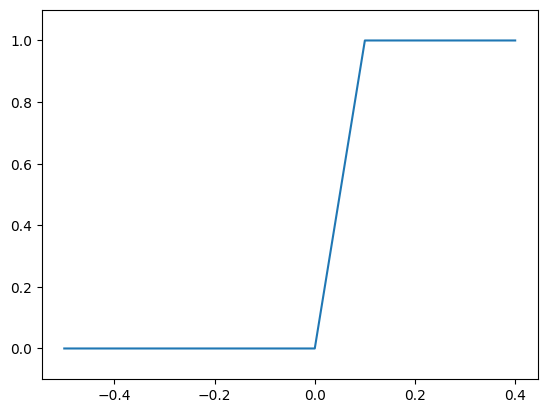

In [ ]:
x = np.arange(-0.5 , 0.5, 0.1)
y = step_function(x)
plt.plot(x,y)
plt.ylim(-0.1,1.1)
plt.show()

In [ ]:
#シグモイド関数の実装
def sigmoid(x):
  return 1 / ( 1 + np.exp(-x) )

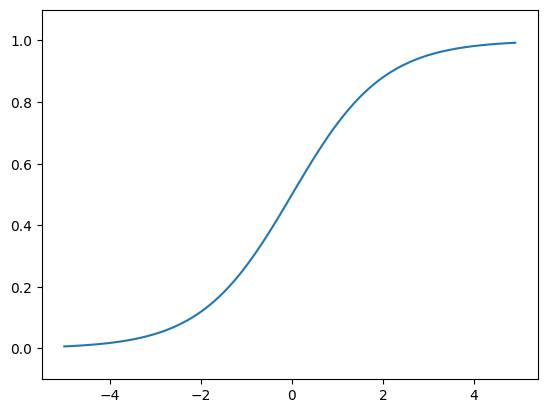

In [ ]:
x = np.arange(-5.0, 5.0, 0.1)
y = sigmoid(x)
plt.plot(x,y)
plt.ylim(-0.1,1.1)
plt.show()

2つの関数の共通点<br>
・最大値最小値<br>
・非線形の関係性<br>
2つの関数の相違点<br>
・非連続か連続か<br>
線形関数を活性化関数と利用すると多層にしなくても同じ表現が可能なため活性化関数は非線形の関数を利用する。

In [ ]:
##ReLU関数
##(max(0,x)の値をとる関数で勾配喪失が起こりにくい、計算が簡単というメリットがある)
def relu(x):
  return np.maximum(0,x)

##簡易的なニューラルネットを構築してみる

In [ ]:
##ニューラルネットのパラメータを設定する関数を定義する
def init_network():
  network = {}
  network["W1"] = np.array([[0.1, 0,3, 0.5],[0.2 ,0.4 ,0.6]])
  network["b1"] = np.array([0.1 ,0.2 ,0.3])
  network["W2"] = np.array([[0.1, 0.4],[0.2 ,0.5],[0.3, 0.6]])
  network["b2"] = np.array([0.1, 0.2])
  network["W3"] = np.array([[0.1, 0.3],[0.2, 0.4]])
  network["b3"] = np.array([0.1, 0.2])
  return network


In [ ]:
##初めの入力を受け取ってニューラルネットの計算する関数を作成
def forward(network, x):
  W1, W2 ,W3 = network["W1"],network["W2"],network["W3"]
  b1, b2 ,b3 = network["b1"],network["b2"],network["b3"]
  a1 = np.dot(x,W1) + b1
  z1 = sigmoid(a1)
  a2 = np.dot(z1,W2) + b2
  z2 = sigmoid(a2)
  a3 = np.dot(z2,W3) + b3
  y = a3
  return y

In [ ]:
network = init_network()
x = np.array([1.0, 0.5])
y = forward(network, x)
print(y)

[0.31682708 0.69627909]


In [ ]:
##softmax関数の実装
##ソフトマックス関数は各値xに対するexp(x)の和を分母にして、分子に任意のaに対するexp(a)を持ってくる。任意の数/全体になるため、確率を表すことができる。

def softmax(a):
  c = np.max(a)
  exp_a = np.exp(a - c)#定数を引くことでおーばフローの対策をする
  sum_exp_a = np.sum(exp_a)
  y = exp_a/sum_exp_a
  return y